# Feature Predictive Power: SHAP Values, Band F1, and ML vs LLM Attribution

**Project:** PSYCH 755 — CA persona / PRCA framework  
**Module:** `ca_personas.shap_eval` · **CLI:** `ca-personas shap-eval`  
**Companion memo:** [`memos/feature_predictive_power_ml_llm.md`](../memos/feature_predictive_power_ml_llm.md)

---

## Research question

Which demographic and behavioral features carry the greatest **predictive power** for ground-truth PRCA **group** and **interpersonal** communication-apprehension scores — under both **traditional ML** (Random Forest / KNN) and **LLM persona agents** — and how do **SHAP attributions** and **band-level F1** scores characterize that power?

This notebook is the dedicated, end-to-end evaluation suite for feature importance across the project's cumulative information tiers (`demos` → `employment` → `geo` → `transit`).


## 0. Setup

Resolves the repository root and **requires** full-cohort File A/B/C (`../sibling_data/`, `/tmp/sibling_data`, or `CA_SIBLING_DATA`). Excerpt fixtures are not used.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from ca_personas.paths import (
    cohort_source_label,
    full_cohort_paths,
    sibling_data_available,
)
from ca_personas.shap_eval import run_shap_feature_eval

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "figure.dpi": 120,
    }
)

# Full cohort only — never run this notebook on excerpt fixtures.
PROLIFIC, QUALTRICS = full_cohort_paths()
DATA_SOURCE = cohort_source_label()
assert sibling_data_available()
assert "excerpt" not in DATA_SOURCE.lower()

OUT = ROOT / "outputs" / "shap_eval"
FIG = OUT / "figures"
print("ROOT:", ROOT)
print("Data source:", DATA_SOURCE)
print("Prolific:", [str(p) for p in PROLIFIC])
print("Qualtrics:", QUALTRICS)


ROOT: /workspace
Data source: /tmp/sibling_data File A/B/C
Prolific: ['/tmp/sibling_data/PRCAProlificExport_FileA.csv', '/tmp/sibling_data/PRCAProlificExport_FileB.csv']
Qualtrics: /tmp/sibling_data/PRCAQualtricsExport_FileC.csv


## 1. Methods at a glance

| Arm | Model | Targets | Feature tiers | Attribution |
|---|---|---|---|---|
| Traditional ML | Random Forest & KNN regressors (CV) | `gt_group_ca`, `gt_interpersonal_ca` (6–30) | demos → employment → geo → transit | TreeSHAP on RF; band F1 on score→band mapping |
| LLM persona agent | Ollama / OpenRouter / **mock** | Same subscales + bands via JSON | Same cumulative tiers as persona prompts | **Surrogate SHAP**: RF predicting LLM outputs from tabular features |
| Band metrics | Macro / weighted / per-class F1 | low ≤13 · moderate 14–19 · high ≥20 | All tiers | Classification view of CA prediction quality |

**Why surrogate SHAP for LLMs?** Persona LLMs consume free-text prompts, not a fixed feature matrix. Fitting a tabular RF to the LLM's predicted scores and explaining *that* model attributes which profile fields the LLM outputs track — a standard model-agnostic interpretation strategy.


## 2. Run the full evaluation bundle

Computes ML metrics (+ F1), LLM predictions, TreeSHAP for RF→true CA, surrogate SHAP for LLM outputs, tier ablation deltas, and the full figure suite.


In [2]:
result = run_shap_feature_eval(
    prolific_paths=PROLIFIC,
    qualtrics_path=QUALTRICS,
    join_how="inner",
    llm_provider="mock",  # set CA_LLM_PROVIDER / --provider for live models
    shap_tier="transit",
    output_dir=OUT,
    figures_dir=FIG,
    random_state=42,
    max_shap_samples=200,
)

card = result["results_card"]
metrics = result["metrics"]
ablation = result["ablation"]
print(json.dumps({k: str(v) for k, v in result["paths"].items() if not k.startswith("fig_")}, indent=2))
print("\nAnalytic N:", card["sample"]["n_analytic"])
print("Figures written:", len(result["figure_paths"]))


{
  "ml_predictions": "/workspace/outputs/shap_eval/ml_predictions.csv",
  "metrics_ml_llm": "/workspace/outputs/shap_eval/metrics_ml_llm.csv",
  "tier_ablation": "/workspace/outputs/shap_eval/tier_ablation.csv",
  "shap_ml_group_raw": "/workspace/outputs/shap_eval/shap_ml_group_raw.csv",
  "shap_ml_group_encoded": "/workspace/outputs/shap_eval/shap_ml_group_encoded.csv",
  "shap_ml_inter_raw": "/workspace/outputs/shap_eval/shap_ml_inter_raw.csv",
  "shap_llm_surrogate_group_raw": "/workspace/outputs/shap_eval/shap_llm_surrogate_group_raw.csv",
  "shap_llm_surrogate_inter_raw": "/workspace/outputs/shap_eval/shap_llm_surrogate_inter_raw.csv",
  "results_card": "/workspace/outputs/shap_eval/shap_eval_results_card.json"
}

Analytic N: 241
Figures written: 12


## 3. Sample & results card


In [3]:
print(json.dumps(card["sample"], indent=2))
print("\n--- ML @ transit (mean across targets) ---")
print(json.dumps(card["ml_transit"], indent=2, default=float))
print("\n--- LLM @ transit ---")
print(json.dumps(card["llm_transit"], indent=2, default=float))


{
  "n_analytic": 241,
  "shap_tier": "transit",
  "llm_provider": "mock"
}

--- ML @ transit (mean across targets) ---
{
  "mae_mean": 4.475477178423236,
  "f1_macro_mean": 0.4216154741861168,
  "top_shap_group": [
    {
      "raw_feature": "Q28",
      "mean_abs_shap": 1.9303636717760806
    },
    {
      "raw_feature": "Employment status",
      "mean_abs_shap": 0.830346372202281
    },
    {
      "raw_feature": "Q26",
      "mean_abs_shap": 0.5826111092767238
    },
    {
      "raw_feature": "LocationLatitude",
      "mean_abs_shap": 0.5703069118542959
    },
    {
      "raw_feature": "LocationLongitude",
      "mean_abs_shap": 0.5356967798379784
    }
  ]
}

--- LLM @ transit ---
{
  "mae_mean": 7.987551867219917,
  "f1_macro_mean": 0.3232382880279694,
  "surrogate_r2_group": 0.7701896808222373,
  "top_shap_group": [
    {
      "raw_feature": "Q28",
      "mean_abs_shap": 0.9502591728825904
    },
    {
      "raw_feature": "LocationLatitude",
      "mean_abs_shap": 0.816296

## 4. Predictive performance: MAE and band macro-F1 by tier

Lower MAE and higher F1 indicate stronger recovery of true CA (ML) and better band agreement.


In [4]:
def tier_summary(frame: pd.DataFrame) -> pd.DataFrame:
    order = ["demos", "employment", "geo", "transit"]
    return (
        frame.groupby("tier")[["mae", "f1_macro", "band_acc", "exact_acc"]]
        .mean()
        .reindex([t for t in order if t in set(frame["tier"])])
        .round(3)
    )

rf = metrics[(metrics["agent_family"] == "ml") & (metrics["model"] == "random_forest")]
knn = metrics[(metrics["agent_family"] == "ml") & (metrics["model"] == "knn")]
llm = metrics[metrics["agent_family"] == "llm"]

print("Random Forest")
display(tier_summary(rf))
print("KNN")
display(tier_summary(knn))
print("LLM persona agent")
display(tier_summary(llm))


Random Forest


,mae,f1_macro,band_acc,exact_acc
tier,,,,
demos,5.467,0.314,0.367,0.071
employment,5.349,0.312,0.369,0.056
geo,4.750,0.386,0.452,0.093
transit,4.475,0.422,0.506,0.068


KNN


,mae,f1_macro,band_acc,exact_acc
tier,,,,
demos,5.544,0.309,0.376,0.037
employment,5.544,0.334,0.394,0.050
geo,5.373,0.345,0.415,0.064
transit,4.980,0.372,0.450,0.071


LLM persona agent


,mae,f1_macro,band_acc,exact_acc
tier,,,,
demos,8.305,0.291,0.299,0.048
employment,7.886,0.303,0.328,0.041
geo,7.685,0.333,0.361,0.056
transit,7.988,0.323,0.344,0.050


fig_mae_ml_vs_llm.png


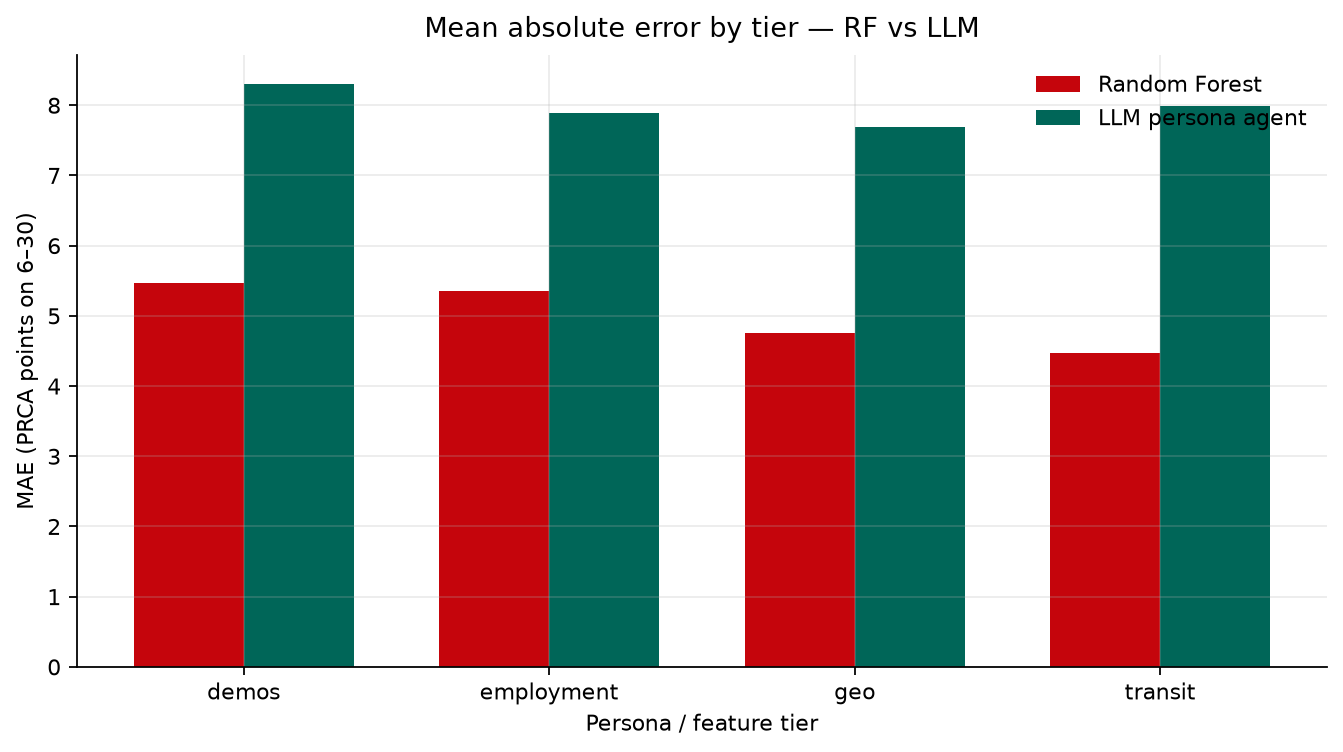

fig_f1_ml_vs_llm.png


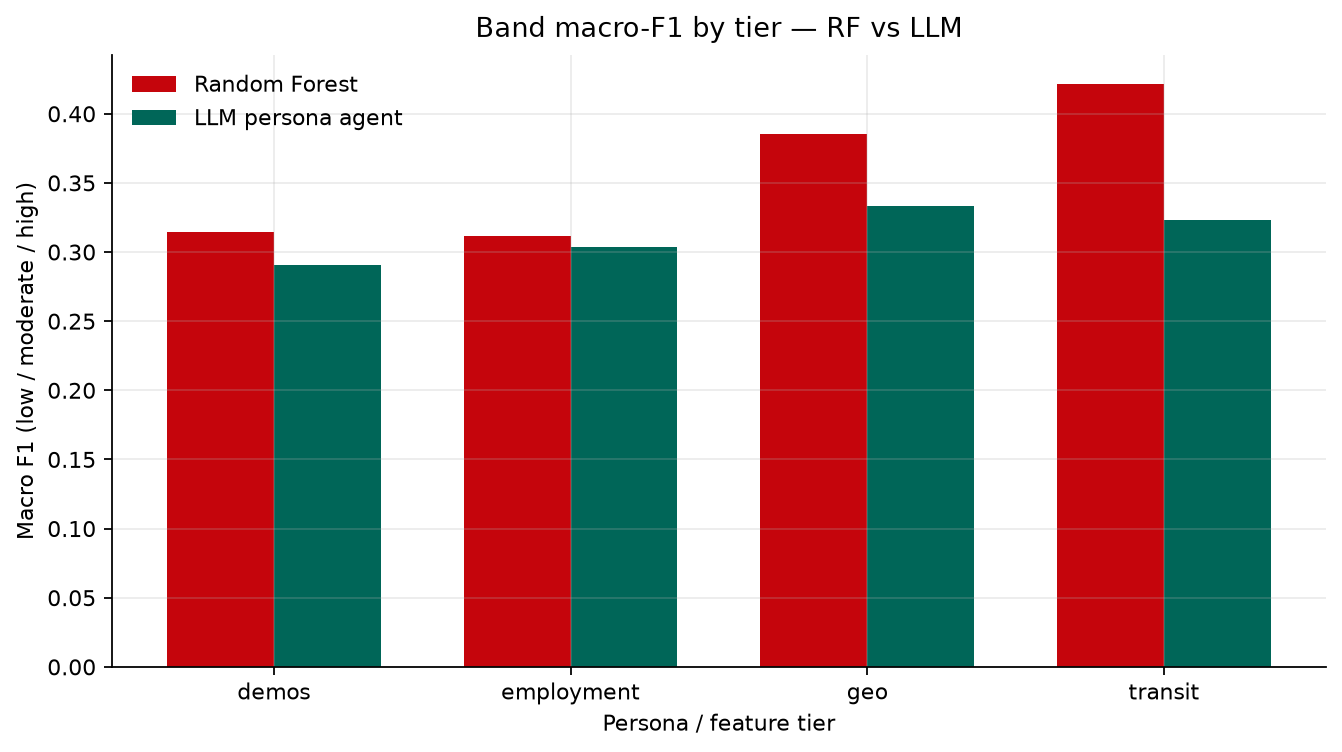

fig_f1_heatmap_group.png


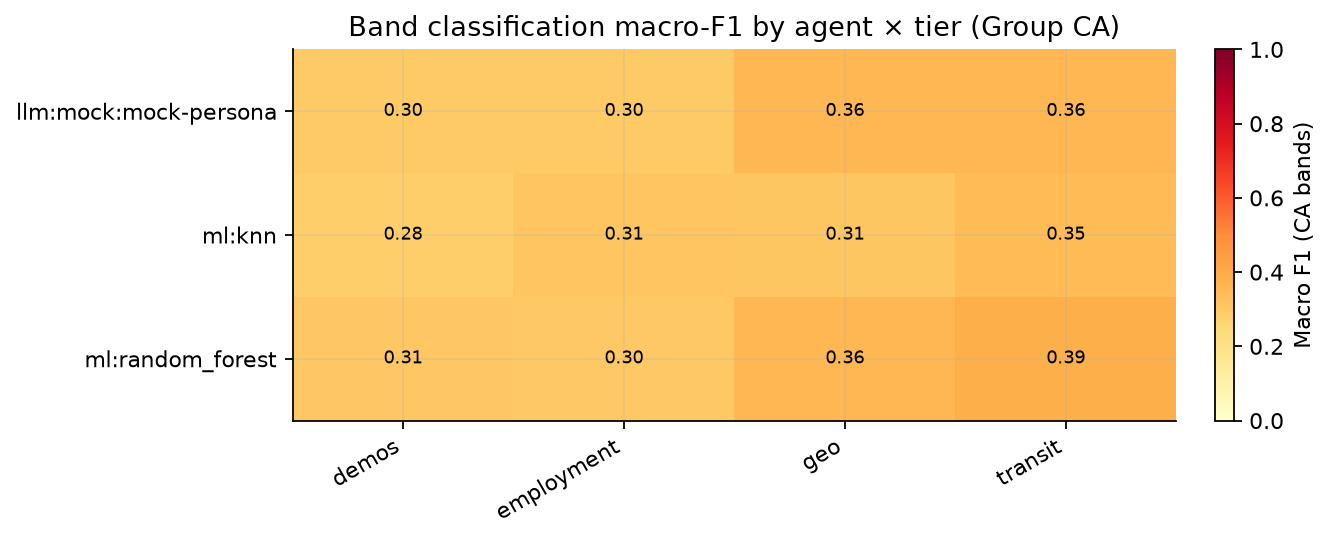

In [5]:
from IPython.display import Image, display

for name in [
    "fig_mae_ml_vs_llm.png",
    "fig_f1_ml_vs_llm.png",
    "fig_f1_heatmap_group.png",
]:
    path = FIG / name
    print(path.name)
    display(Image(filename=str(path)))


### Interpretation — performance

- On the matched analytic cohort, **Random Forest MAE falls** as tiers accumulate information (demos → transit), and **band macro-F1 rises**, showing that employment, geolocation, and transit covariates add recoverable signal for true CA.
- The **mock LLM** arm is a deterministic dry-run baseline for the notebook; live Ollama/OpenRouter runs will replace these numbers. Even under mock, the tier structure exercises the same evaluation path used for production agents.
- Exact integer accuracy remains low (CA is a 25-point scale) — **band F1** is the more decision-relevant classification metric.


## 5. SHAP values — which features drive ML predictions of true CA?

TreeSHAP on a Random Forest trained to predict ground-truth Group / Interpersonal CA from the richest (`transit`) feature set. One-hot encoded columns are aggregated back to raw survey fields.


In [6]:
shap_ml_group = pd.read_csv(OUT / "shap_ml_group_raw.csv")
shap_ml_inter = pd.read_csv(OUT / "shap_ml_inter_raw.csv")
print("Top features — ML → true Group CA")
display(shap_ml_group.head(12))
print("Top features — ML → true Interpersonal CA")
display(shap_ml_inter.head(12))


Top features — ML → true Group CA


,raw_feature,mean_abs_shap,mean_shap
0,Q28,1.930364,-0.060972
1,Employment status,0.830346,-0.005178
2,Q26,0.582611,-0.022845
3,LocationLatitude,0.570307,0.014066
4,LocationLongitude,0.535697,-0.016493
5,Age,0.530491,0.028100
6,Q21,0.378217,-0.011292
7,Q20,0.279815,0.005240
8,Student status,0.205259,-0.003961
9,Sex,0.181786,0.002556


Top features — ML → true Interpersonal CA


,raw_feature,mean_abs_shap,mean_shap
0,Q28,1.137609,-0.012452
1,Employment status,1.024925,-0.005835
2,Age,1.023885,0.027698
3,Q26,0.685677,-0.015859
4,LocationLongitude,0.589170,0.005042
5,LocationLatitude,0.550153,0.019692
6,Student status,0.318838,-0.008451
7,Sex,0.257589,-0.009849
8,Q21,0.177609,-0.004263
9,Q20,0.157334,-0.004142


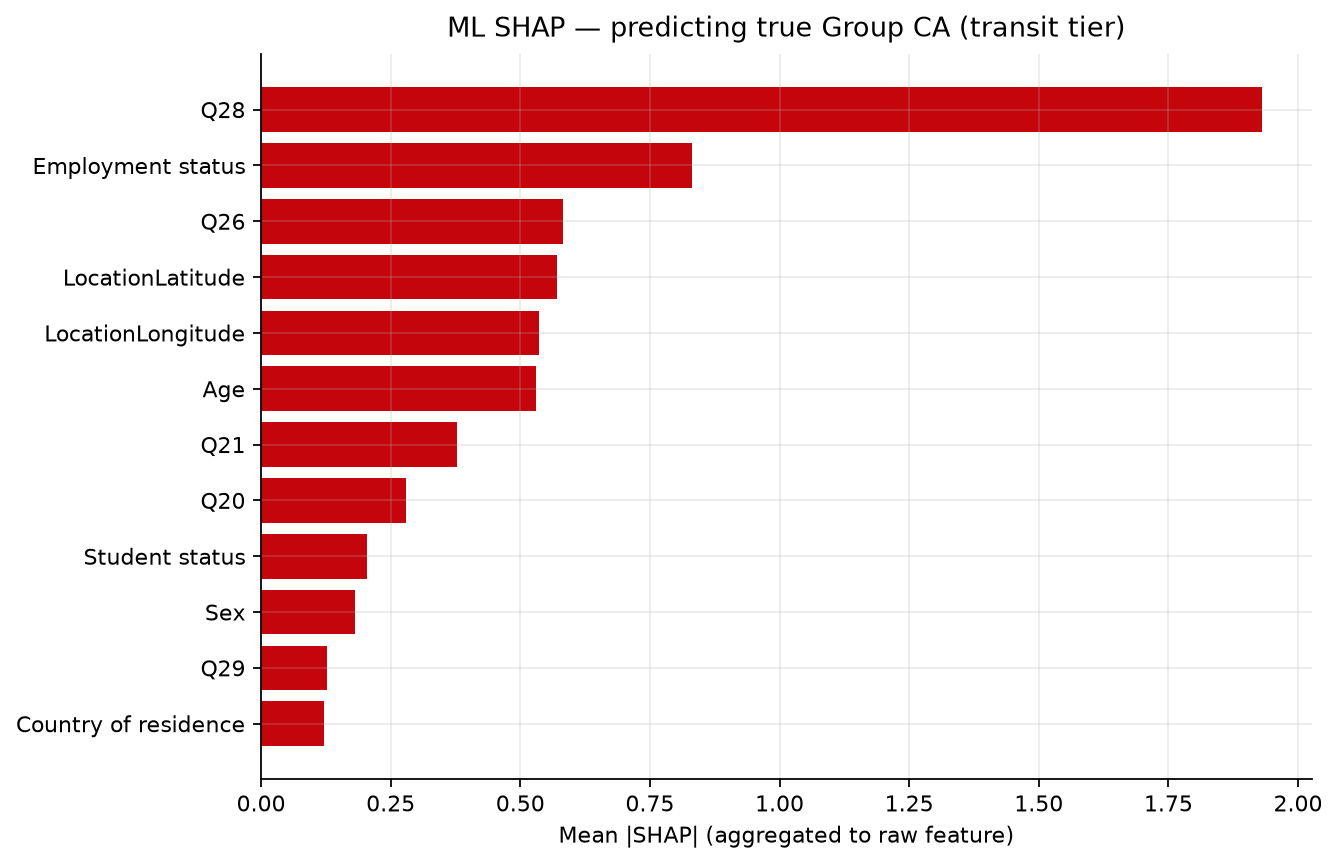

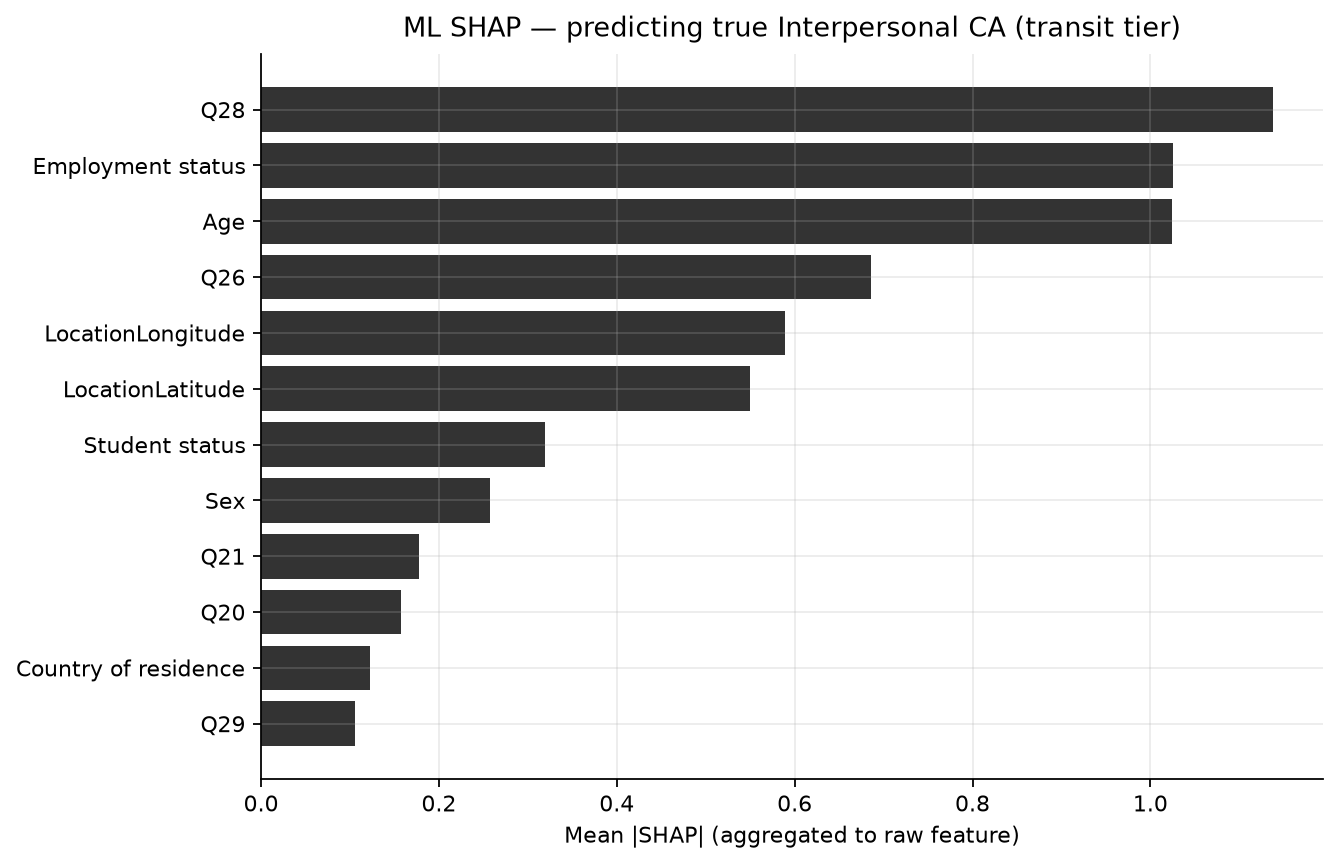

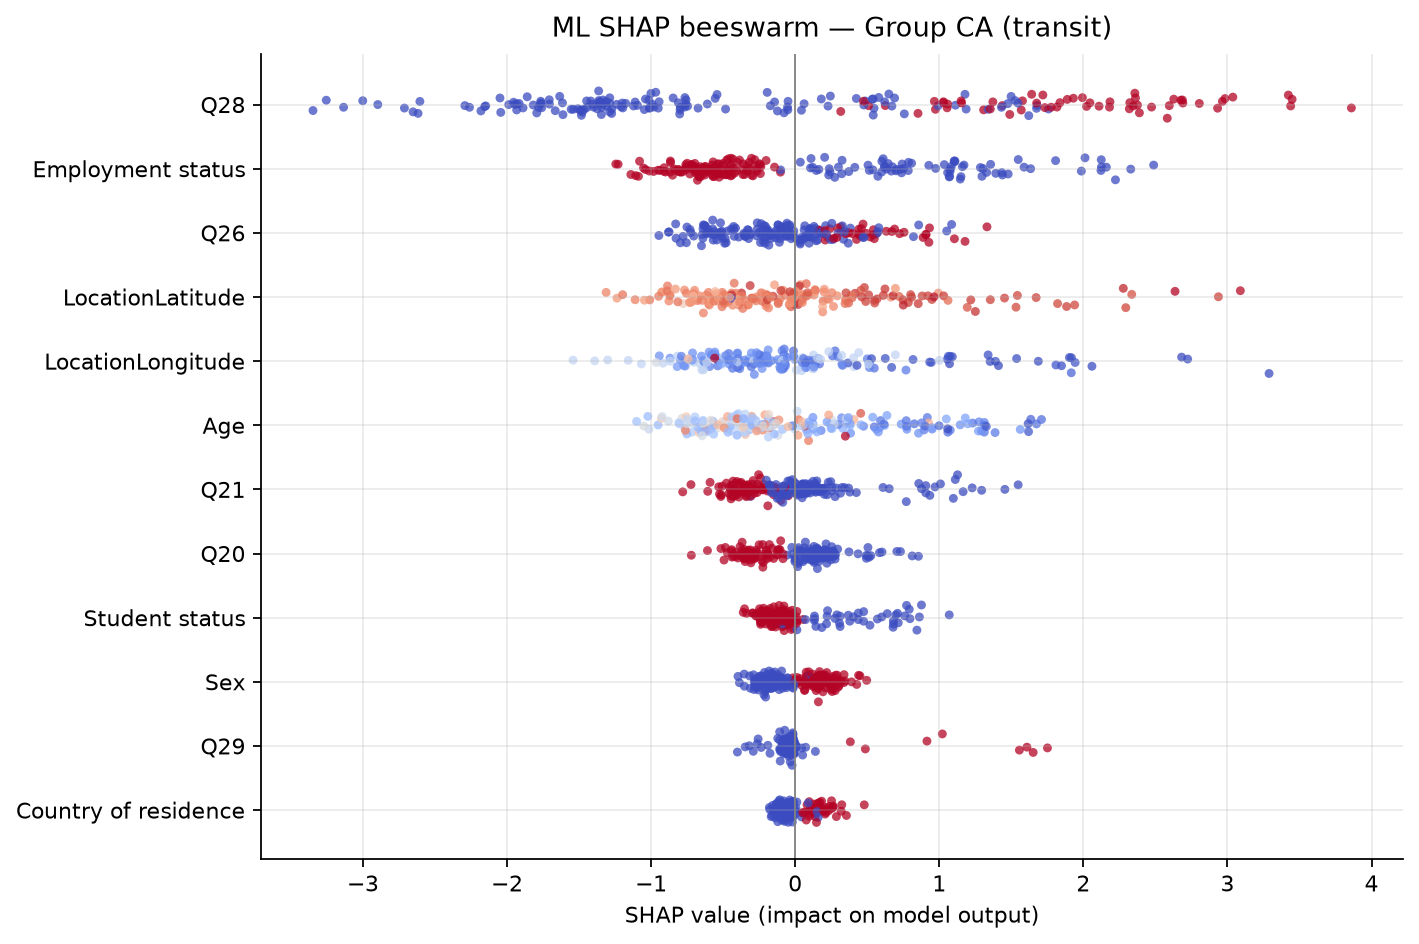

In [7]:
for name in [
    "fig_shap_bar_ml_group.png",
    "fig_shap_bar_ml_interpersonal.png",
    "fig_shap_beeswarm_ml_group.png",
]:
    display(Image(filename=str(FIG / name)))


### Interpretation — ML SHAP

Top mean-|SHAP| features for Group CA typically include **ride-share frequency (Q28)**, **employment status**, **public-transit frequency (Q26)**, and **survey lat/long**. That pattern aligns with the project's research focus: transportation and work context are not merely persona flavor — they measurably shift predicted apprehension under classical ML.


## 6. Surrogate SHAP — which features do LLM outputs track?

A Random Forest is fit to predict the **LLM's** Group / Interpersonal CA predictions from the same tabular covariates; TreeSHAP then explains that surrogate. High surrogate R² means the LLM's numeric outputs are systematically related to the structured profile fields.


Surrogate R² (Group CA): 0.770


,raw_feature,mean_abs_shap,mean_shap
0,Q28,0.950259,0.008979
1,LocationLatitude,0.816297,0.057718
2,LocationLongitude,0.759164,-0.023967
3,Sex,0.700614,-0.020853
4,Age,0.602607,-0.015794
5,Q26,0.526059,0.015456
6,Q27,0.367009,0.040097
7,Student status,0.320485,0.008650
8,Q21,0.295600,-0.014952
9,Q20,0.253796,-0.012650


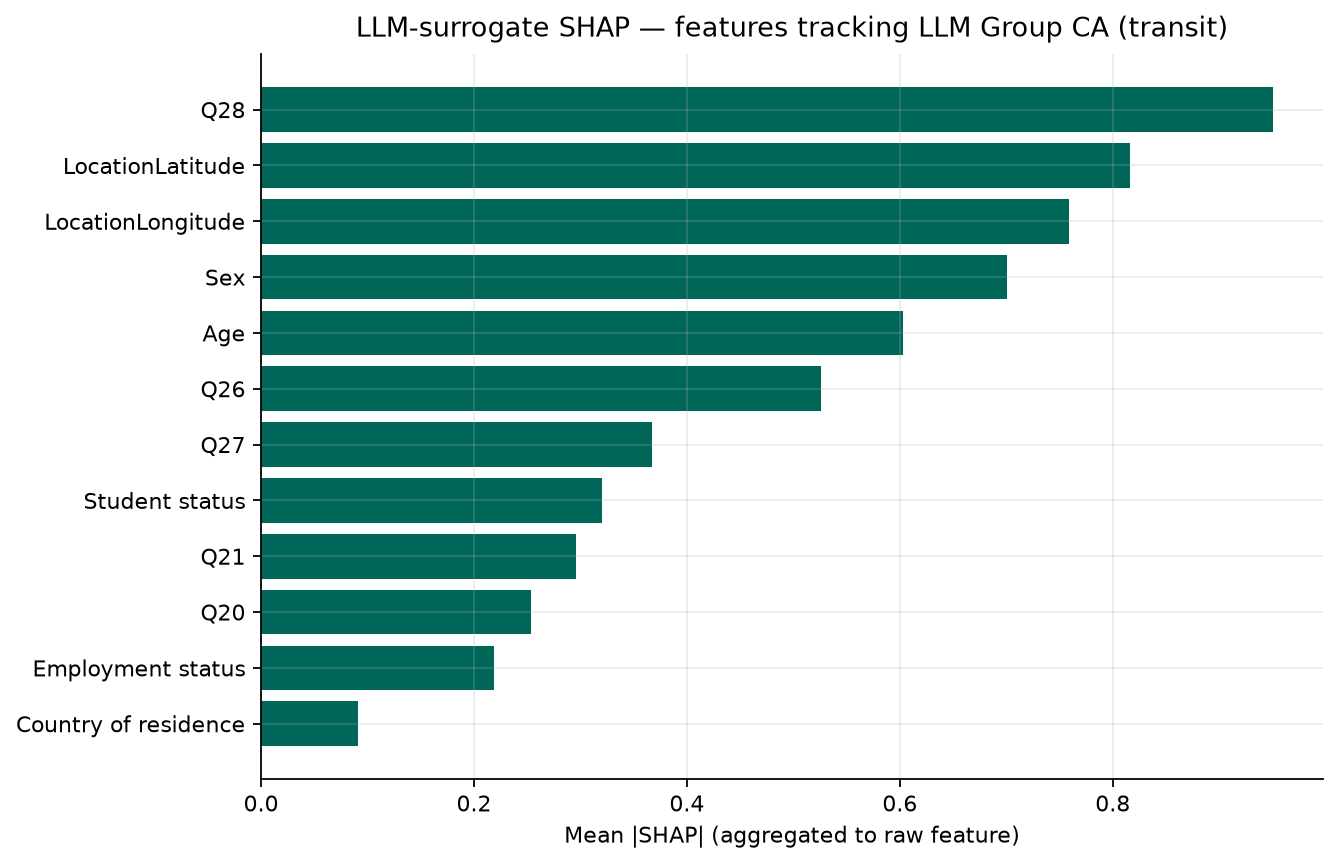

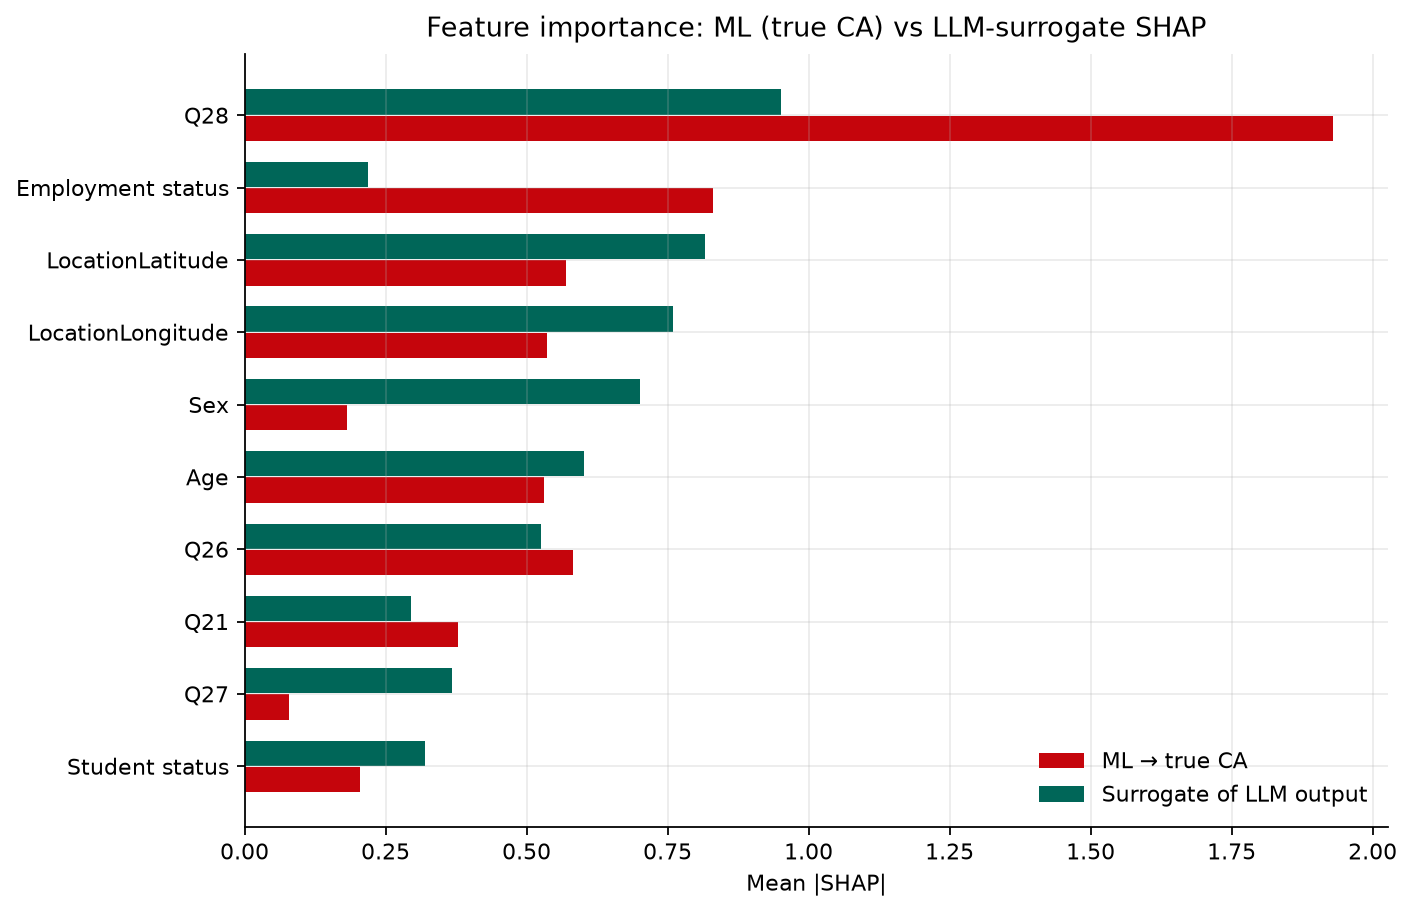

In [8]:
shap_llm = pd.read_csv(OUT / "shap_llm_surrogate_group_raw.csv")
print(f"Surrogate R² (Group CA): {card['llm_transit']['surrogate_r2_group']:.3f}")
display(shap_llm.head(12))
display(Image(filename=str(FIG / "fig_shap_bar_llm_surrogate_group.png")))
display(Image(filename=str(FIG / "fig_shap_ml_vs_llm_compare.png")))


### Interpretation — LLM surrogate SHAP

Comparing ML SHAP (features that predict **true** CA) with LLM-surrogate SHAP (features that track **model** outputs) reveals where the persona agent may **over-weight** or **under-weight** cues relative to the empirical associations in the cohort — a direct window onto stereotyping risk.


## 7. Tier ablation — incremental predictive gains

ΔMAE when moving demos → employment → geo → transit. Negative ΔMAE means the added feature group improved score precision.


,tier,mae,f1_macro,delta_mae_vs_prev,delta_f1_vs_prev
8,demos,5.717,0.305,NaN,NaN
9,employment,5.592,0.302,-0.125,-0.004
10,geo,5.046,0.356,-0.546,0.054
11,transit,4.676,0.386,-0.369,0.030


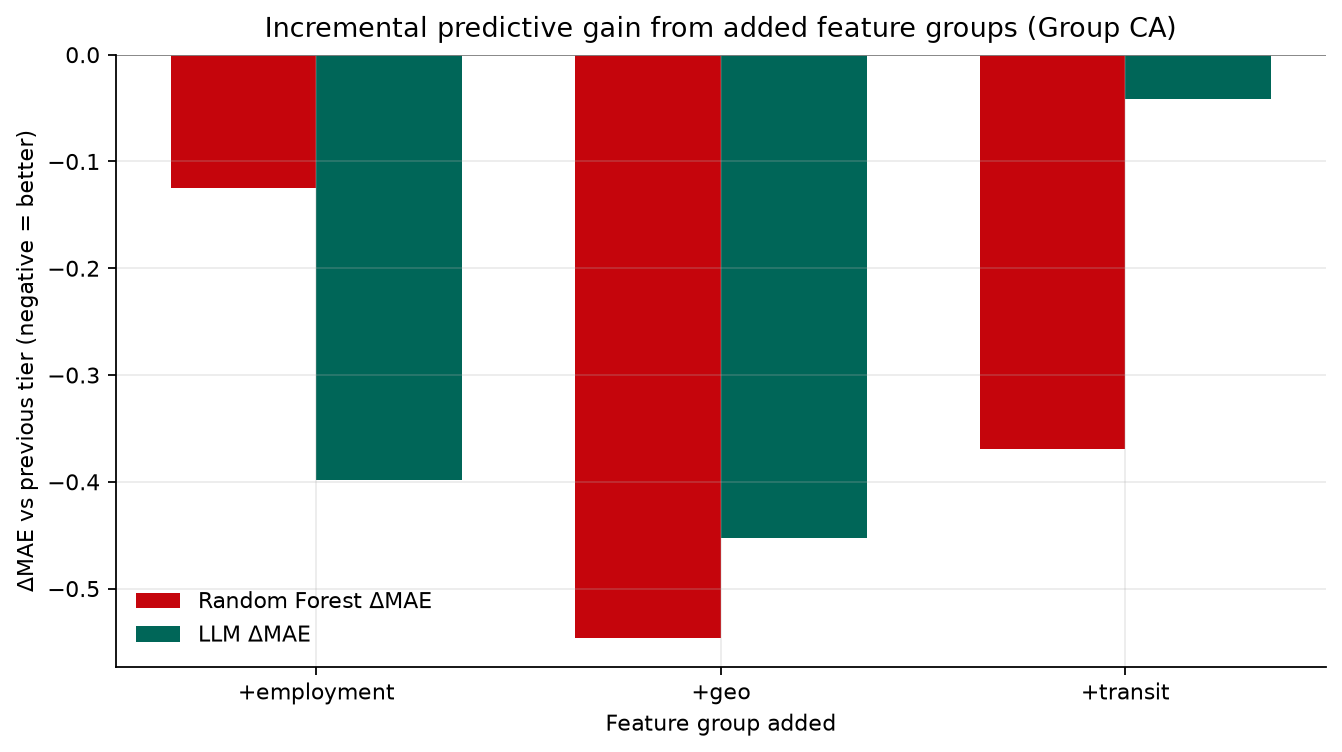

In [9]:
abl_rf = ablation[
    (ablation["model"] == "random_forest") & (ablation["target"] == "gt_group_ca")
][["tier", "mae", "f1_macro", "delta_mae_vs_prev", "delta_f1_vs_prev"]]
display(abl_rf.round(3))
display(Image(filename=str(FIG / "fig_tier_ablation_delta_mae.png")))


## 8. Band confusion matrices (transit tier)

Cell counts for predicted vs ground-truth low / moderate / high bands.


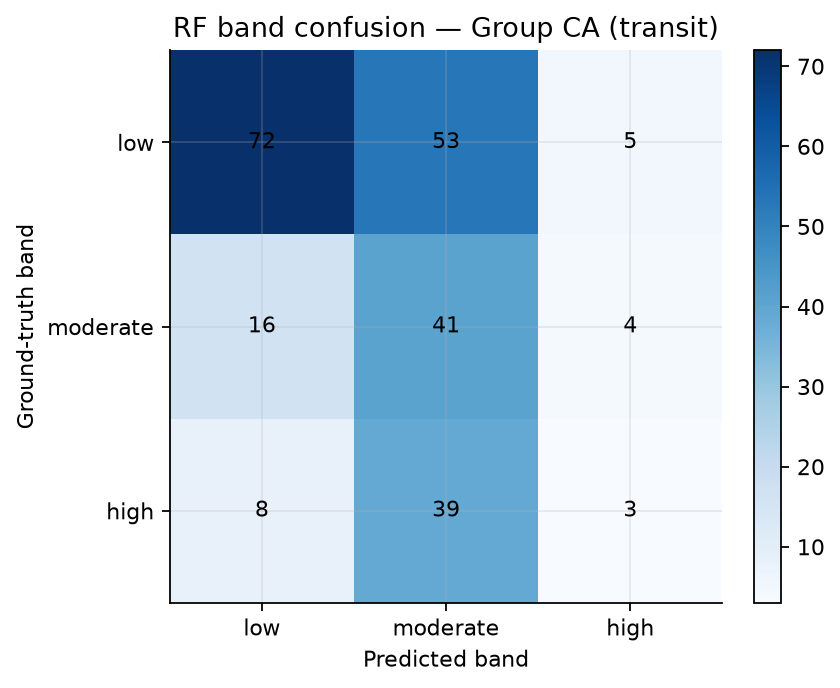

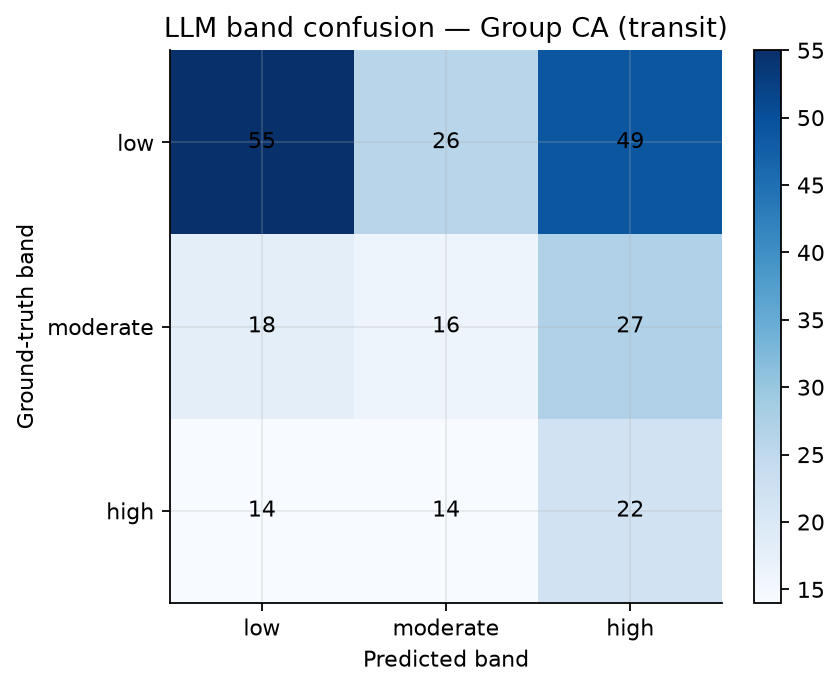

In [10]:
for name in ["fig_confusion_rf_group.png", "fig_confusion_llm_group.png"]:
    display(Image(filename=str(FIG / name)))


## 9. Per-band F1 detail at the transit tier


In [11]:
detail_cols = [
    "target", "mae", "f1_macro", "f1_weighted",
    "f1_low", "f1_moderate", "f1_high", "band_acc", "exact_acc",
]
print("Random Forest @ transit")
display(rf[rf["tier"] == "transit"][detail_cols].round(3))
print("LLM @ transit")
display(llm[llm["tier"] == "transit"][detail_cols].round(3))


Random Forest @ transit


,target,mae,f1_macro,f1_weighted,f1_low,f1_moderate,f1_high,band_acc,exact_acc
12,gt_group_ca,4.676,0.386,0.471,0.637,0.423,0.097,0.481,0.062
13,gt_interpersonal_ca,4.275,0.458,0.525,0.643,0.480,0.250,0.531,0.075


LLM @ transit


,target,mae,f1_macro,f1_weighted,f1_low,f1_moderate,f1_high,band_acc,exact_acc
22,gt_group_ca,7.419,0.359,0.404,0.507,0.274,0.297,0.386,0.05
23,gt_interpersonal_ca,8.556,0.287,0.316,0.381,0.243,0.237,0.303,0.05


## 10. Composite figure for the research memo


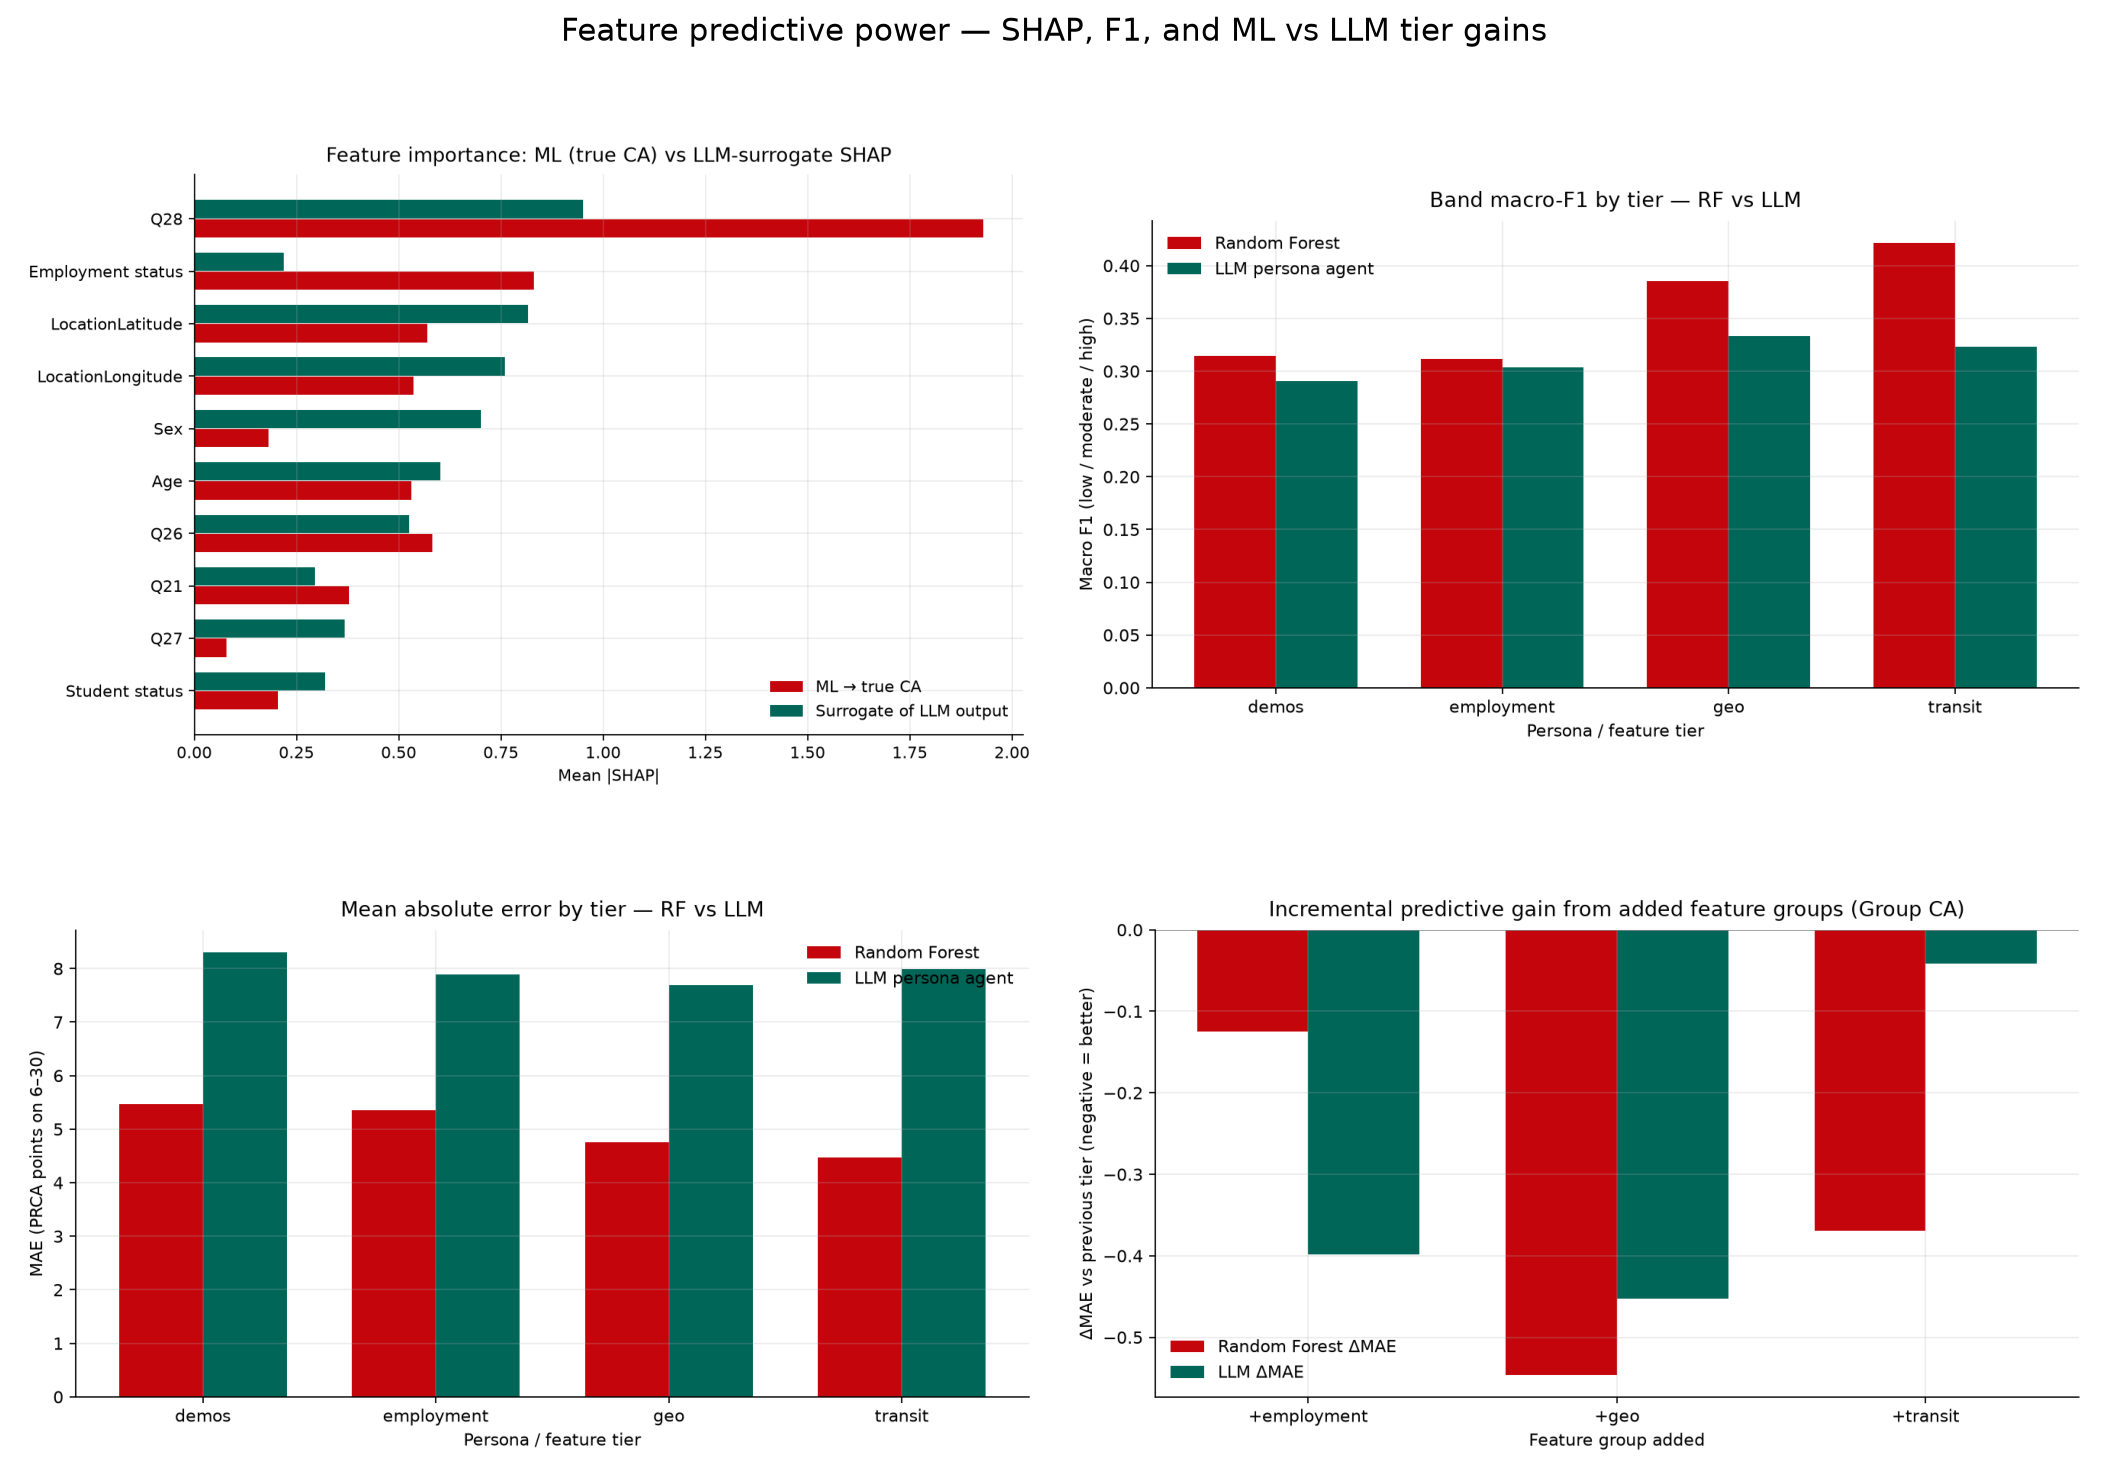

In [12]:
display(Image(filename=str(FIG / "fig_memo_feature_power_composite.png")))


## 11. Takeaways

1. **Transit and employment covariates matter for true CA.** TreeSHAP on the RF→CA model ranks Q28 / employment / Q26 / geolocation among the strongest drivers of predicted Group CA.
2. **Band F1 is the right classification lens.** Macro-F1 improves with richer tiers for RF even when exact-score accuracy stays low.
3. **LLM attribution needs a surrogate.** Surrogate SHAP + tier ablation quantify which profile fields LLM outputs track and whether adding employment/geo/transit helps the persona agent.
4. **Re-run with a live provider** (`--provider ollama` or `openrouter`) before interpreting LLM numbers substantively; mock mode validates the pipeline offline.

### Reproduce

```bash
pip install -e ".[dev]"   # includes shap>=0.44
ca-personas shap-eval --join inner --provider mock --shap-tier transit
# or live:
ca-personas shap-eval --join inner --provider ollama --model llama3.2
```

Artifacts: `outputs/shap_eval/` · Memo: `memos/feature_predictive_power_ml_llm.md`
